# 철강 표면 결함 분류 — Dropout_2

96×96 흑백 이미지에서 열연 강판의 표면 결함 6종 분류


## 1. 환경 설정

In [1]:
import copy
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: mps


## 2. 데이터 소개

**NEU Surface Defect Database**의 이미지 분류용 데이터

- 대상: 열연 강판 표면
- 원본: 200×200 흑백 이미지
- 모델 입력: 96×96 흑백 이미지
- 정답: 표면 결함 6종
- 샘플: 클래스당 300장, 총 1,800장
- 분할: Train 1,440 / Validation 180 / Test 180

| 클래스 | 의미 |
|---|---|
| `crazing` | 미세 균열망 |
| `inclusion` | 개재물 |
| `patches` | 불규칙 반점 |
| `pitted_surface` | 점식·패임 표면 |
| `rolled-in_scale` | 압입 산화피막 |
| `scratches` | 긁힘 |

> 출처: Northeastern University의 NEU 표면 결함 데이터. Kaggle 배포본은 라이선스가 명시되지 않아 교육 목적으로 사용합니다. [데이터 설명](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database)


### 폴더 구조

KaggleHub로 원본 데이터 자동 다운로드

```text
NEU-DET/
├── train/images/클래스명/*.jpg
└── validation/images/클래스명/*.jpg
```

- `train`: 학습 데이터
- `validation`: 클래스별 30장은 검증, 30장은 테스트에 사용
- `annotations`: 객체탐지용 XML이므로 이번 분류 실습에서는 제외


## 3. 데이터 불러오기

In [2]:
path = kagglehub.dataset_download(
    "kaustubhdikshit/neu-surface-defect-database"
)

data_root = Path(path) / "NEU-DET"
train_root = data_root / "train" / "images"
heldout_root = data_root / "validation" / "images"

class_names = sorted(folder.name for folder in train_root.iterdir() if folder.is_dir())
rng = np.random.default_rng(SEED)

train_samples = []
val_samples = []
test_samples = []

for class_id, class_name in enumerate(class_names):
    train_files = sorted((train_root / class_name).glob("*.jpg"))
    heldout_files = sorted((heldout_root / class_name).glob("*.jpg"))
    order = rng.permutation(len(heldout_files))

    val_files = [heldout_files[i] for i in order[:30]]
    test_files = [heldout_files[i] for i in order[30:]]

    train_samples.extend((file, class_id) for file in train_files)
    val_samples.extend((file, class_id) for file in val_files)
    test_samples.extend((file, class_id) for file in test_files)

print("data path:", data_root)
print("classes  :", class_names)
print("split    :", len(train_samples), len(val_samples), len(test_samples))


data path: /Users/han/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET
classes  : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
split    : 1440 180 180


### 클래스별 이미지

In [3]:
plt.figure(figsize=(12, 6))

for class_id, class_name in enumerate(class_names):
    examples = [file for file, label in train_samples if label == class_id][:2]

    for column, file in enumerate(examples):
        plot_index = class_id * 2 + column + 1
        plt.subplot(3, 4, plot_index)
        plt.imshow(Image.open(file).convert("L"), cmap="gray")
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 12 Axes>

## 4. Dataset과 DataLoader 
4. ~~증강 추가 - 이미지 반전~~\
10\. ~~증강 다시 추가 - 이미지 반전, 회전~~

In [4]:
image_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])


class SteelDefectDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file, label = self.samples[index]
        image = Image.open(file).convert("L")
        image = self.transform(image)
        return image, label


train_dataset = SteelDefectDataset(train_samples, image_transform)
val_dataset = SteelDefectDataset(val_samples, image_transform)
test_dataset = SteelDefectDataset(test_samples, image_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))
print("image batch:", batch_images.shape)
print("label batch:", batch_labels.shape)


image batch: torch.Size([64, 1, 96, 96])
label batch: torch.Size([64])


## 5.1 수정 모델
1. Convolution Layer 추가
2. ~~Regularization - Fully Connected Layer에 Dropout 추가~~
3. Normalization - Batch Normalization 추가\
11\. Convolution Layer 추가\
12\. Regularization - Convolution Layer 과 Fully Connected Layer 사이,\
    Fully Connected Layer에 Dropout 추가

In [5]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 각 Convolutional Layer와 첫 번째 Fully Connected Layer 뒤에 Batch Normalization을 적용해 학습을 안정화합니다.
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolutional Block 3개를 추가해 채널 수를 8에서 16, 32, 64로 단계적으로 확장합니다.
            nn.Conv2d(8, 16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=5),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=5),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolutional Feature Map에 Dropout(p=0.25)을 적용해 25%를 무작위로 비활성화하고 과적합을 완화합니다.
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 2 * 2, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Fully Connected Layer 출력에 Dropout(p=0.5)을 적용해 50%를 무작위로 비활성화하고 과적합을 완화합니다.
            nn.Dropout(0.5),
            nn.Linear(32, 6),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = BaselineCNN().to(device)
print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): ReLU()
    (15)

## 6. 손실 함수와 옵티마이저
5. Learning Rate 조정\
8\. Scheduler 추가\
9\. patience 4 --> 2\
12\. patience 2 --> 4

In [6]:
loss_fn = nn.CrossEntropyLoss()

# Adam Optimizer의 Learning Rate를 3e-4로 설정해 Parameter 갱신 폭을 조절합니다.
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# Validation Loss가 정체되면 Learning Rate를 factor=0.5에 따라 절반으로 낮춥니다.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,

    # Validation Loss 정체에 대한 허용 범위를 patience=4로 설정합니다.
    patience=4,
    min_lr=1e-6,
)

## 7. 학습
6. Epoch 조정
7. Early Stopping 추가

In [7]:
def run_epoch(model, loader, training=False):
    model.train() if training else model.eval()
    total_loss = 0.0
    correct = 0
    count = 0

    with torch.set_grad_enabled(training):
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            predictions = model(batch_images)
            loss = loss_fn(predictions, batch_labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(batch_images)
            correct += (predictions.argmax(1) == batch_labels).sum().item()
            count += len(batch_images)

    return total_loss / count, correct / count

In [8]:
# 최대 학습 횟수를 200 Epoch로 설정하고 Early Stopping 조건을 함께 사용합니다.
EPOCHS = 200

# Validation Loss의 유의미한 개선이 없는 상태를 최대 6 Epoch까지 허용합니다.
EARLY_STOPPING_PATIENCE = 6
MIN_DELTA = 1e-4
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_weights = None
best_epoch = 0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, training=True)
    val_loss, val_acc = run_epoch(model, val_loader)

    # 현재 Validation Loss를 Learning Rate Scheduler에 전달해 다음 Epoch의 Learning Rate 조정 여부를 갱신합니다.
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Validation Loss가 기존 최저값보다 최소 1e-4 감소한 경우에만 개선으로 인정합니다.
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train {train_loss:.3f}, {train_acc:.3f} | "
        f"val {val_loss:.3f}, {val_acc:.3f} | "
        f"lr {current_lr:.1e} | "
        f"patience {patience_counter}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )

    # 유의미한 개선이 없는 Epoch가 6회 누적되면 Early Stopping으로 학습을 종료합니다.
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping: epoch {epoch}에서 학습을 종료합니다.")
        break

# 학습 종료 후 Validation Loss가 가장 낮았던 Epoch의 가중치를 복원합니다.
model.load_state_dict(best_weights)
print(f"Best epoch: {best_epoch}, Best validation loss: {best_val_loss:.3f}")

Epoch 01 | train 1.584, 0.371 | val 1.855, 0.222 | lr 3.0e-04 | patience 0/6
Epoch 02 | train 1.300, 0.574 | val 1.837, 0.239 | lr 3.0e-04 | patience 0/6
Epoch 03 | train 1.182, 0.659 | val 1.368, 0.489 | lr 3.0e-04 | patience 0/6
Epoch 04 | train 1.080, 0.721 | val 1.196, 0.633 | lr 3.0e-04 | patience 0/6
Epoch 05 | train 0.980, 0.774 | val 1.228, 0.556 | lr 3.0e-04 | patience 1/6
Epoch 06 | train 0.913, 0.798 | val 1.198, 0.589 | lr 3.0e-04 | patience 2/6
Epoch 07 | train 0.848, 0.826 | val 1.017, 0.739 | lr 3.0e-04 | patience 0/6
Epoch 08 | train 0.809, 0.830 | val 0.965, 0.711 | lr 3.0e-04 | patience 0/6
Epoch 09 | train 0.746, 0.857 | val 0.829, 0.833 | lr 3.0e-04 | patience 0/6
Epoch 10 | train 0.705, 0.868 | val 0.783, 0.817 | lr 3.0e-04 | patience 0/6
Epoch 11 | train 0.679, 0.861 | val 0.762, 0.833 | lr 3.0e-04 | patience 0/6
Epoch 12 | train 0.635, 0.874 | val 0.732, 0.856 | lr 3.0e-04 | patience 0/6
Epoch 13 | train 0.586, 0.901 | val 0.745, 0.772 | lr 3.0e-04 | patience 1/6

## 8. 학습 곡선

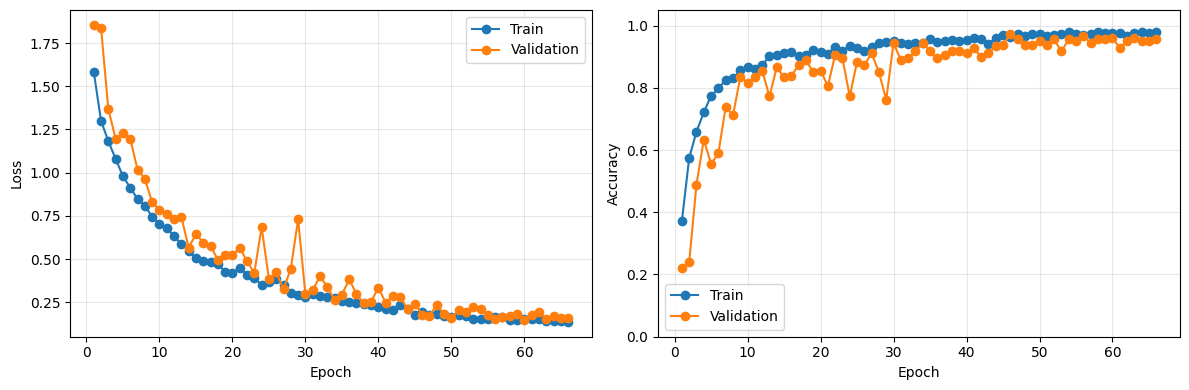

In [9]:
# Early Stopping 여부와 관계없이 실제 기록된 Epoch 수에 맞춰 x축을 생성합니다.
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 9. Validation 성능


In [10]:
def predict(model, loader):
    model.eval()
    answers = []
    predictions = []

    with torch.no_grad():
        for batch_images, batch_labels in loader:
            outputs = model(batch_images.to(device))
            predictions.extend(outputs.argmax(1).cpu().numpy())
            answers.extend(batch_labels.numpy())

    return np.asarray(answers), np.asarray(predictions)


val_answers, val_predictions = predict(model, val_loader)
val_accuracy = accuracy_score(val_answers, val_predictions)
val_f1 = f1_score(val_answers, val_predictions, average="macro")

print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Validation Macro F1: {val_f1:.3f}")

Validation Accuracy: 0.961
Validation Macro F1: 0.961


### 혼동행렬

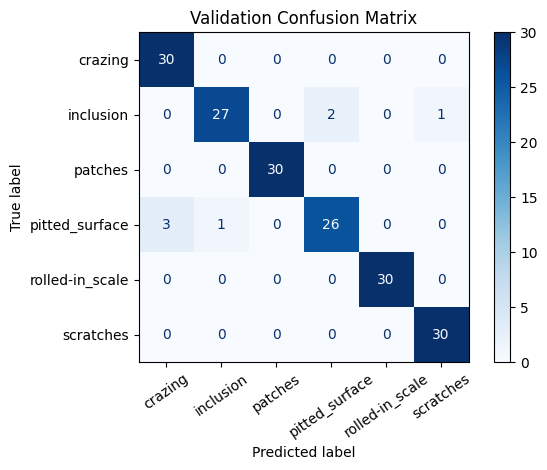

In [11]:
ConfusionMatrixDisplay.from_predictions(
    val_answers,
    val_predictions,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=35,
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Validation 예측 결과


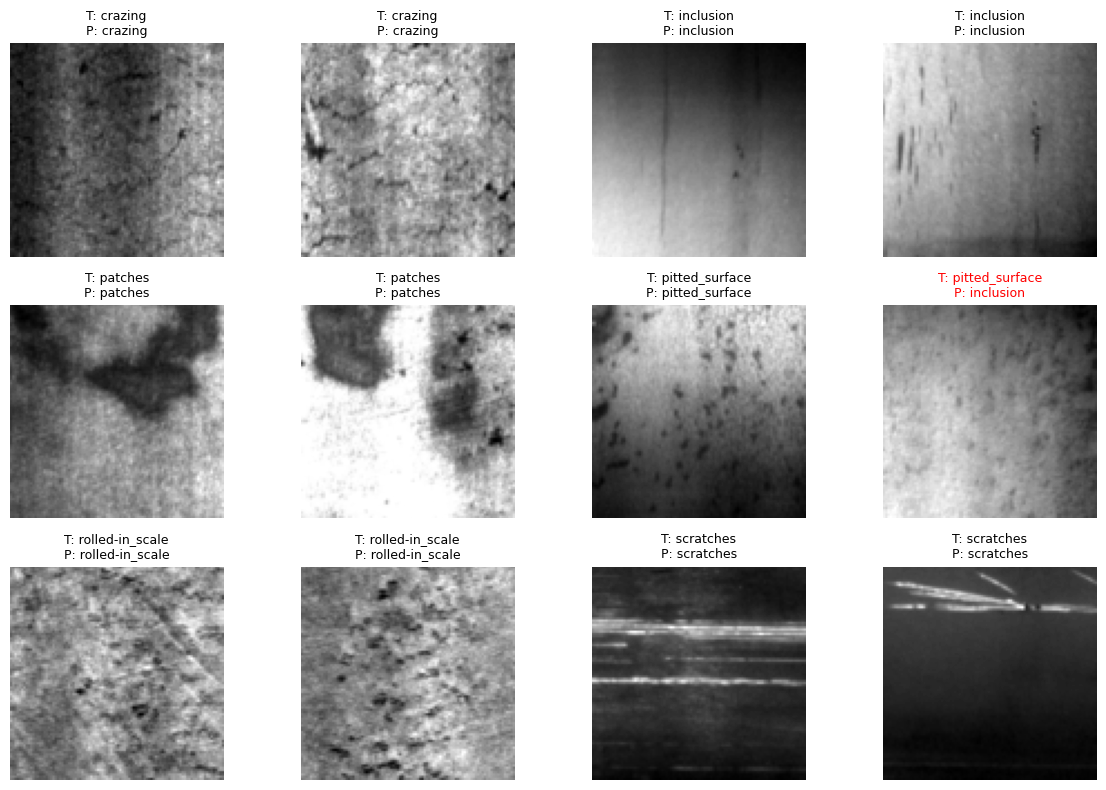

In [12]:
plt.figure(figsize=(12, 8))

sample_indices = []
for class_id in range(len(class_names)):
    indices = [i for i, (_, label) in enumerate(val_samples) if label == class_id]
    sample_indices.extend(indices[:2])

for plot_index, data_index in enumerate(sample_indices, start=1):
    image, answer = val_dataset[data_index]

    with torch.no_grad():
        prediction = model(image.unsqueeze(0).to(device)).argmax(1).item()

    color = "black" if prediction == answer else "red"

    plt.subplot(3, 4, plot_index)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"T: {class_names[answer]}\nP: {class_names[prediction]}",
        color=color,
        fontsize=9,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 11. Test 성능

Validation 데이터로 모델 선택과 튜닝을 마친 뒤, Test 데이터로 최종 일반화 성능을 한 번만 평가한다.


Test Accuracy: 0.972
Test Macro F1: 0.972


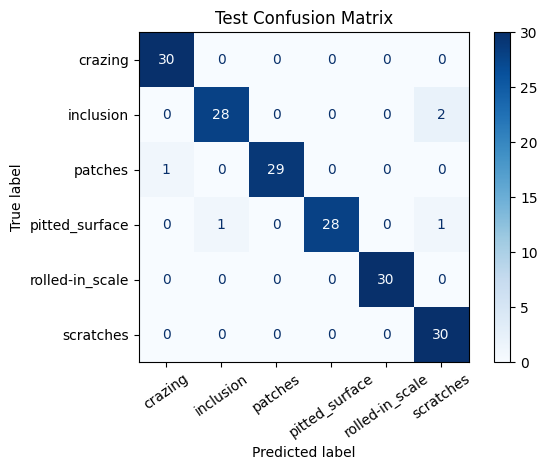

In [13]:
# 최저 Validation Loss의 가중치를 복원한 모델로 Test 성능을 최종 평가합니다.
test_answers, test_predictions = predict(model, test_loader)
test_accuracy = accuracy_score(test_answers, test_predictions)
test_f1 = f1_score(test_answers, test_predictions, average="macro")

print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Test Macro F1: {test_f1:.3f}")

ConfusionMatrixDisplay.from_predictions(
    test_answers,
    test_predictions,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=35,
)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()


## 12. Feature map

Feature map: 합성곱 필터의 반응 결과


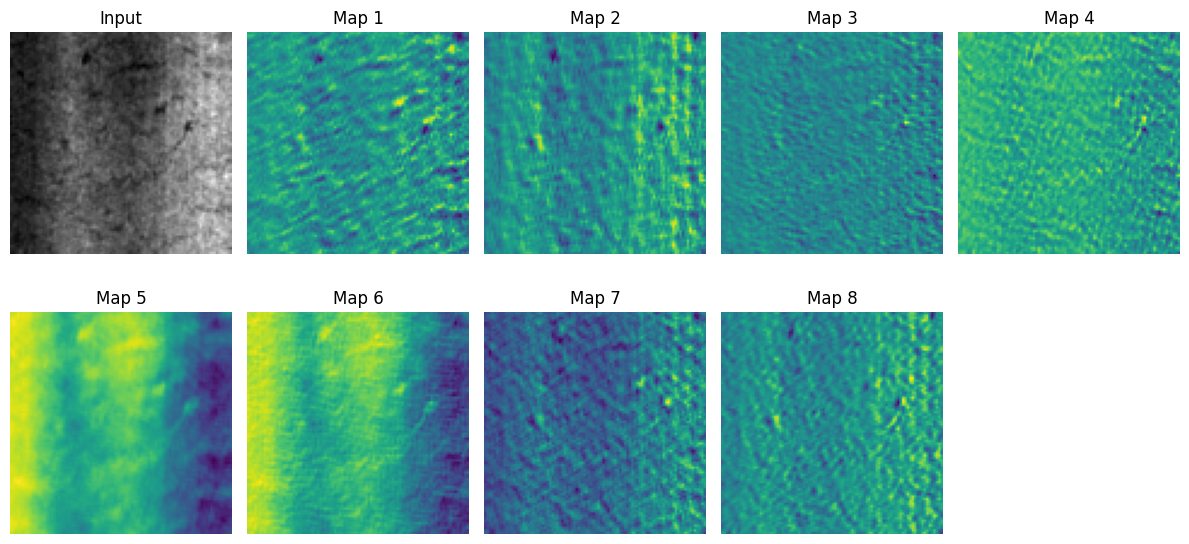

In [14]:
def show_feature_maps(model, layer, image, max_maps=8):
    activation = {}

    def save_output(module, inputs, output):
        activation["maps"] = output.detach().cpu()

    hook = layer.register_forward_hook(save_output)

    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    hook.remove()

    maps = activation["maps"][0]
    count = min(max_maps, len(maps))

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 5, 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    for i in range(count):
        plt.subplot(2, 5, i + 2)
        plt.imshow(maps[i], cmap="viridis")
        plt.title(f"Map {i + 1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# 첫 번째 Convolutional Layer 뒤의 Batch Normalization 출력을 시각화합니다.
sample_image, _ = val_dataset[0]
show_feature_maps(model, model.features[1], sample_image)


## 13. Baseline 진단

다음 항목을 확인하고 종합실습의 최적화 목표를 정한다.

1. Train과 Validation 성능 차이에서 어떤 문제가 보이는가?
2. 가장 많이 혼동하는 클래스와 오분류 이미지의 특징은 무엇인가?
3. Validation 성능과 과적합을 함께 개선하려면 무엇을 먼저 변경할 것인가?
4. 변경 결과를 어떤 지표로 판단할 것인가?

> 별도 답안은 제출하지 않으며, 분석 결과를 종합실습 보고서의 `Baseline 진단`에 반영한다.
